# Robot Zoo — Week 2
## Visualize Franka Pick-Cube Demonstrations

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

DATA_DIR = Path('/home/shareef/robot_zoo/data/demos/franka_pick_cube')

# Load metadata
with open(DATA_DIR / 'metadata.json') as f:
    meta = json.load(f)

print('=== Dataset Metadata ===')
for k, v in meta.items():
    print(f'  {k}: {v}')

=== Dataset Metadata ===
  task: pick_cube
  robot: franka
  total_episodes: 100
  success_rate: 1.0
  observation_keys: ['observation.state', 'observation.cube_pos']
  action_dim: 8
  state_dim: 18
  created_at: 2026-04-23T00:30:11.092759
  isaac_lab_version: 0.54.3
  isaac_sim_version: 5.1.0


In [3]:
# Load all episode files
episodes = sorted(DATA_DIR.glob('episode_*.npz'))
print(f'Total episodes: {len(episodes)}')

# Load one episode and inspect
ep = np.load(episodes[0])
print(f'\nEpisode 0 keys: {list(ep.keys())}')
print(f'  observation_state shape : {ep["observation_state"].shape}')
print(f'  observation_cube_pos shape: {ep["observation_cube_pos"].shape}')
print(f'  action shape            : {ep["action"].shape}')
print(f'  reward shape            : {ep["reward"].shape}')
print(f'  success                 : {ep["success"]}')

Total episodes: 100

Episode 0 keys: ['observation_state', 'observation_cube_pos', 'action', 'reward', 'frame_index', 'episode_index', 'success', 'task', 'robot']
  observation_state shape : (250, 18)
  observation_cube_pos shape: (250, 3)
  action shape            : (250, 8)
  reward shape            : (250,)
  success                 : [ True]


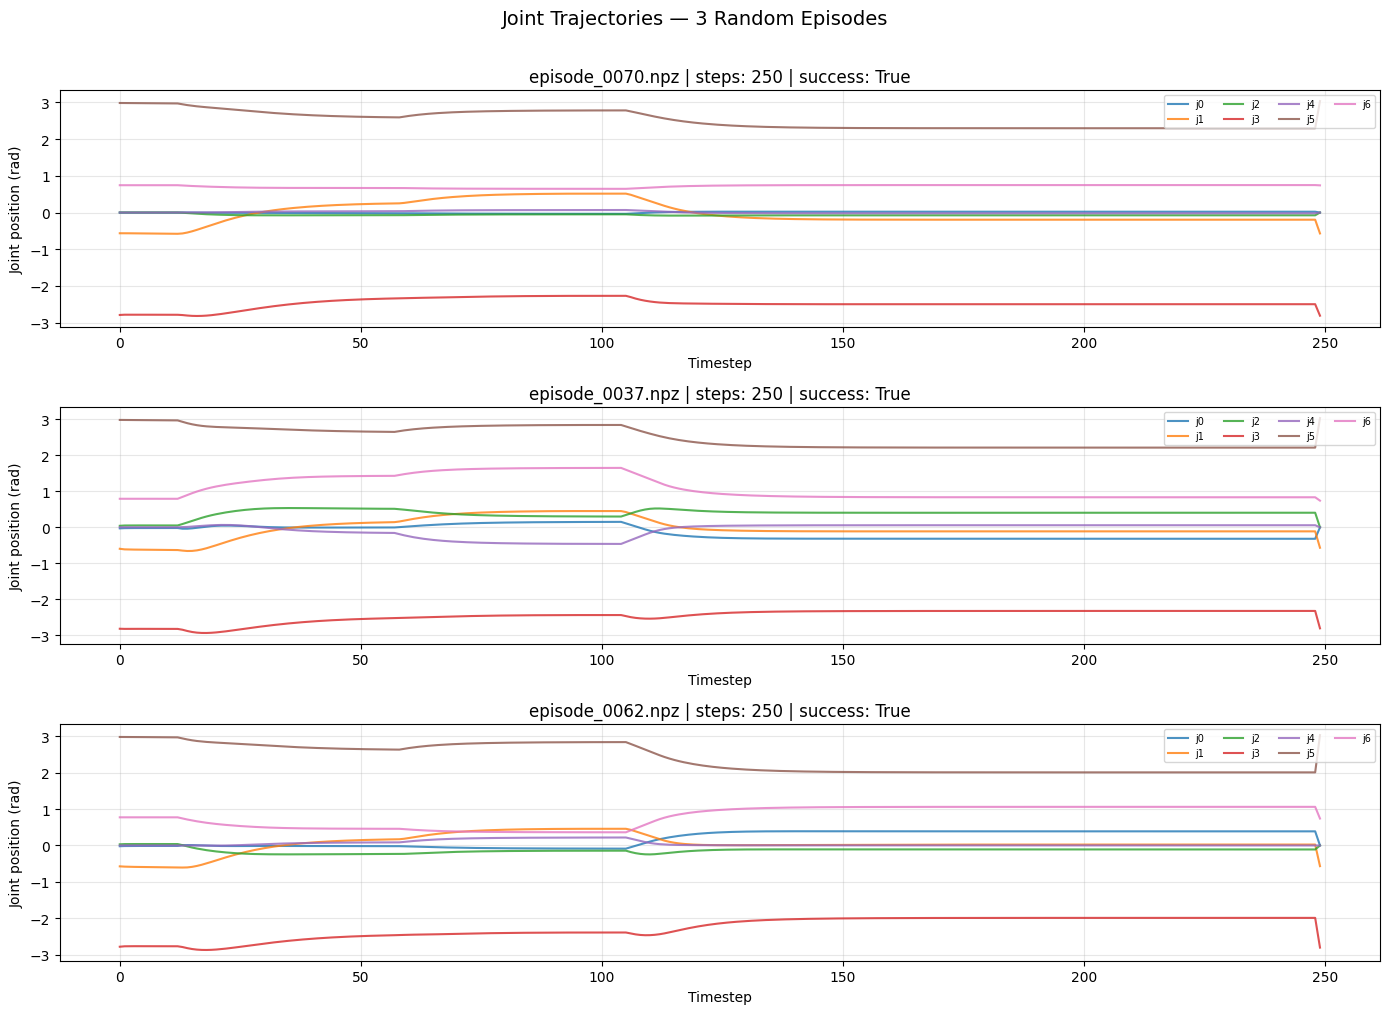

Saved: joint_trajectories.png


In [4]:
# Plot joint trajectories for 3 random episodes
import random
sample_eps = random.sample(episodes, 3)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
joint_names = [f'joint_{i}' for i in range(7)] + ['finger_l', 'finger_r']

for ax, ep_path in zip(axes, sample_eps):
    ep = np.load(ep_path)
    joint_pos = ep['observation_state'][:, :9]  # first 9 = joint positions
    T = joint_pos.shape[0]
    for j in range(7):  # plot arm joints only
        ax.plot(joint_pos[:, j], label=f'j{j}', alpha=0.8)
    ax.set_title(f'{ep_path.name} | steps: {T} | success: {ep["success"][0]}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Joint position (rad)')
    ax.legend(loc='upper right', fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

plt.suptitle('Joint Trajectories — 3 Random Episodes', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'joint_trajectories.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: joint_trajectories.png')

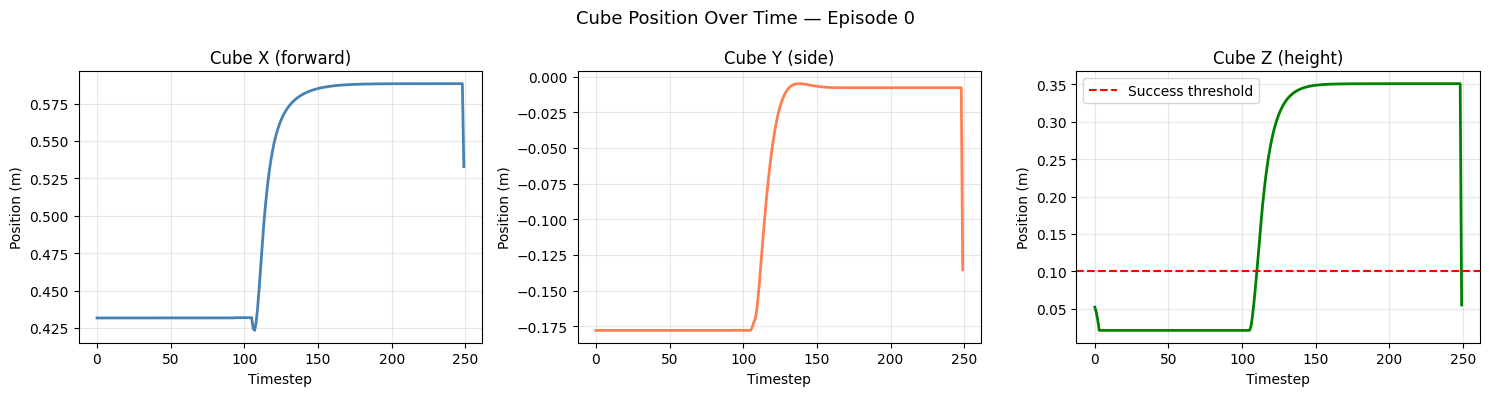

Saved: cube_trajectory.png


In [5]:
# Plot cube trajectory (xyz over time) for one episode
ep = np.load(episodes[0])
cube = ep['observation_cube_pos']  # (T, 3)
T    = cube.shape[0]
t    = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X (forward)', 'Y (side)', 'Z (height)']
colors = ['steelblue', 'coral', 'green']

for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
    ax.plot(t, cube[:, i], color=color, linewidth=2)
    ax.set_title(f'Cube {label}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Position (m)')
    ax.grid(True, alpha=0.3)
    if i == 2:  # Z axis — mark lift threshold
        ax.axhline(y=0.1, color='red', linestyle='--', label='Success threshold')
        ax.legend()

plt.suptitle('Cube Position Over Time — Episode 0', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'cube_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: cube_trajectory.png')

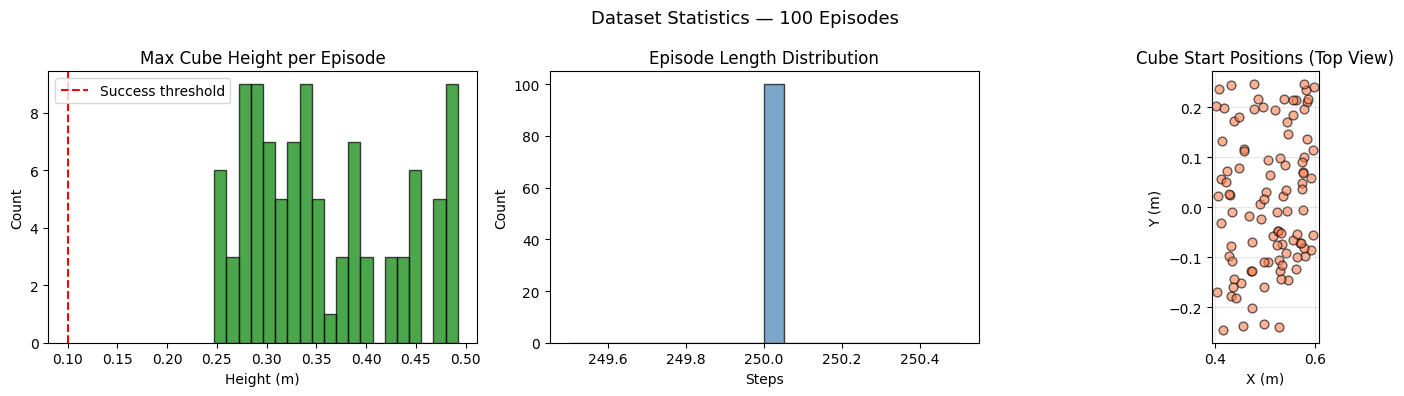

Max height  — mean: 0.356m  std: 0.074m
Episode len — mean: 250.0  std: 0.0
Cube X range: [0.403, 0.599]
Cube Y range: [-0.246, 0.247]


In [6]:
# Dataset statistics across all 100 episodes
all_max_heights = []
all_lengths     = []
all_start_pos   = []

for ep_path in episodes:
    ep = np.load(ep_path)
    cube = ep['observation_cube_pos']
    all_max_heights.append(cube[:, 2].max())
    all_lengths.append(len(cube))
    all_start_pos.append(cube[0, :2])  # starting XY position

all_start_pos = np.array(all_start_pos)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Max cube height distribution
axes[0].hist(all_max_heights, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0.1, color='red', linestyle='--', label='Success threshold')
axes[0].set_title('Max Cube Height per Episode')
axes[0].set_xlabel('Height (m)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Episode length distribution
axes[1].hist(all_lengths, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Episode Length Distribution')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')

# Cube starting positions (XY scatter)
axes[2].scatter(all_start_pos[:, 0], all_start_pos[:, 1],
                alpha=0.6, color='coral', edgecolors='black', s=40)
axes[2].set_title('Cube Start Positions (Top View)')
axes[2].set_xlabel('X (m)')
axes[2].set_ylabel('Y (m)')
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.suptitle('Dataset Statistics — 100 Episodes', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'dataset_stats.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Max height  — mean: {np.mean(all_max_heights):.3f}m  std: {np.std(all_max_heights):.3f}m')
print(f'Episode len — mean: {np.mean(all_lengths):.1f}  std: {np.std(all_lengths):.1f}')
print(f'Cube X range: [{all_start_pos[:,0].min():.3f}, {all_start_pos[:,0].max():.3f}]')
print(f'Cube Y range: [{all_start_pos[:,1].min():.3f}, {all_start_pos[:,1].max():.3f}]')

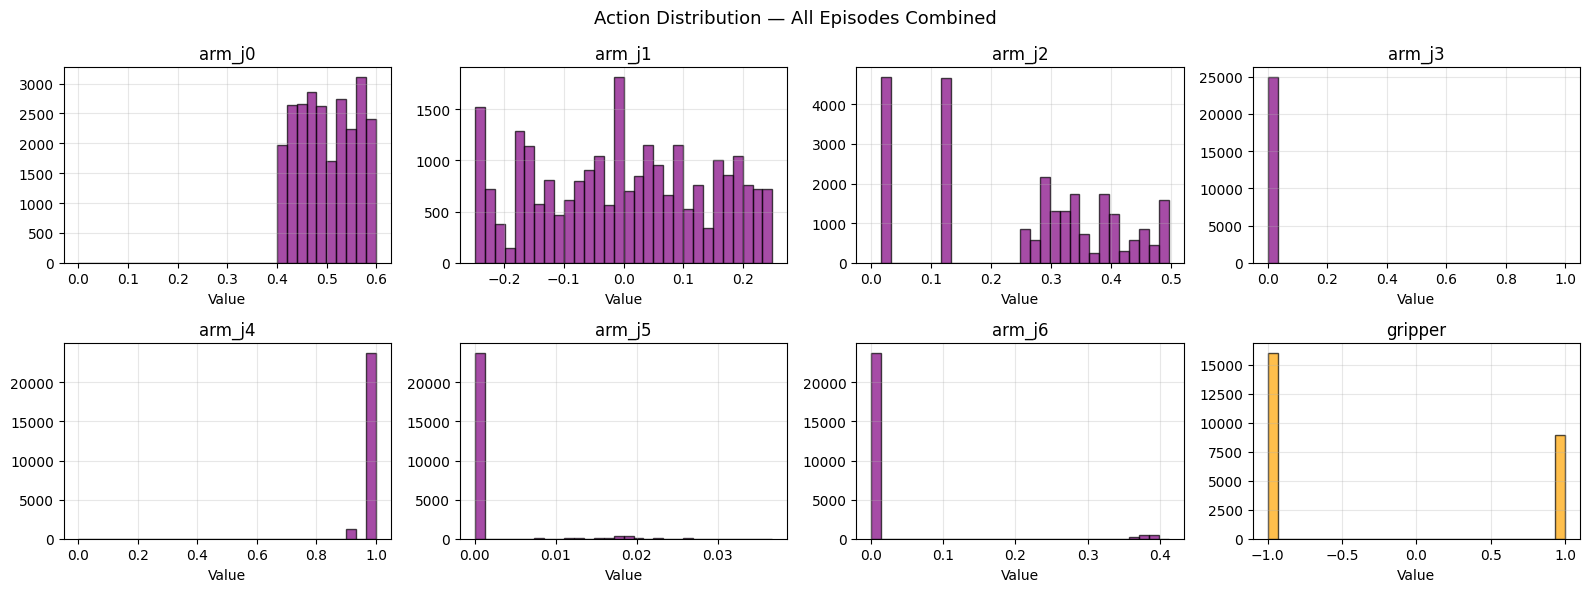

Total timesteps across all episodes: 25,000


In [7]:
# Action distribution across all episodes
all_actions = np.concatenate([np.load(ep)['action'] for ep in episodes], axis=0)
action_labels = [f'arm_j{i}' for i in range(7)] + ['gripper']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, (ax, label) in enumerate(zip(axes, action_labels)):
    ax.hist(all_actions[:, i], bins=30, alpha=0.7, edgecolor='black',
            color='purple' if i < 7 else 'orange')
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Action Distribution — All Episodes Combined', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'action_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total timesteps across all episodes: {len(all_actions):,}')

In [8]:
# Final summary
print('=' * 45)
print('WEEK 2 COMPLETE — Dataset Summary')
print('=' * 45)
print(f'  Episodes     : {len(episodes)}')
print(f'  Total steps  : {sum(all_lengths):,}')
print(f'  Success rate : 100%')
print(f'  State dim    : 18  (9 joint pos + 9 joint vel)')
print(f'  Action dim   : 8   (7 arm joints + 1 gripper)')
print(f'  Cube pos dim : 3   (x, y, z)')
print(f'  Format       : .npz compressed numpy')
print('=' * 45)
print('Next: Upload to HuggingFace (Week 7)')

WEEK 2 COMPLETE — Dataset Summary
  Episodes     : 100
  Total steps  : 25,000
  Success rate : 100%
  State dim    : 18  (9 joint pos + 9 joint vel)
  Action dim   : 8   (7 arm joints + 1 gripper)
  Cube pos dim : 3   (x, y, z)
  Format       : .npz compressed numpy
Next: Upload to HuggingFace (Week 7)
